# Task 1: Exploratory Data Analysis & Preprocessing

**Project**: Policy Optimization for Financial Decision-Making  
**Author**: Shreyansh Singh  
**Date**: October 2025

In [370]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [371]:
#Setup paths
PROJECT_ROOT = Path('.').absolute().parent
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DATA_DIR = DATA_DIR / 'raw'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'

# Create directories if they don't exist
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directories:")
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_DIR}")

Project directories:
Project Root: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization
Data Directory: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/data


## 1. Data Loading

### Download Instructions:
If you haven't downloaded the data yet:

**Option 1: Using Kaggle API (Recommended)**
```bash
# Install kaggle: pip install kaggle
# Setup API credentials: https://github.com/Kaggle/kaggle-api#api-credentials
kaggle datasets download -d wordsforthewise/lending-club
unzip lending-club.zip -d ../data/raw/
```

**Option 2: Manual Download**
1. Go to: https://www.kaggle.com/datasets/wordsforthewise/lending-club
2. Download `accepted_2007_to_2018Q4.csv.gz`
3. Place it in `../data/raw/` folder

In [373]:
#Load the dataset
DATA_FILE = RAW_DATA_DIR / 'accepted_2007_to_2018Q4.csv.gz'

if not DATA_FILE.exists():
    print("Data file not found!")
    print(f"Expected location: {DATA_FILE}")
    print("\nPlease download the data using the instructions above.")
else:
    print(" Data file found! Loading...")
    
    
    df_raw = pd.read_csv(DATA_FILE, compression='gzip', low_memory=False)
    
    print(f"\n Data loaded successfully!")
    print(f"Shape: {df_raw.shape}")
    print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

 Data file found! Loading...

 Data loaded successfully!
Shape: (2260701, 151)
Memory usage: 5992.29 MB


In [374]:
# Display first 5 rows
df_raw.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

In [375]:
#dataset information
print("Dataset Information:")
print(f"Number of rows: {len(df_raw):,}")
print(f"Number of columns: {len(df_raw.columns)}")
print(f"\nColumn names:")
print(df_raw.columns.tolist())

Dataset Information:
Number of rows: 2,260,701
Number of columns: 151

Column names:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_t

## 2. Target Variable Analysis

The target variable `loan_status` indicates the current status of the loan.

In [377]:
# loan_status distribution
print("Loan Status Distribution:")
print(df_raw['loan_status'].value_counts())
print(f"\nPercentages:")
print(df_raw['loan_status'].value_counts(normalize=True) * 100)

Loan Status Distribution:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Percentages:
loan_status
Fully Paid                                             47.629771
Current                                                38.852100
Charged Off                                            11.879630
Late (31-120 days)                                      0.949587
In Grace Period                                         0.373164
Late (16-30 days) 

In [378]:
# Filter to completed loans only
#We only want loans with definitive outcomes (not "Current" or "In Grace Period")
completed_statuses = [
    'Fully Paid',
    'Charged Off',
    'Default',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
]

df = df_raw[df_raw['loan_status'].isin(completed_statuses)].copy()

print(f" Filtered to completed loans")
print(f"Original size: {len(df_raw):,} rows")
print(f"Filtered size: {len(df):,} rows")
print(f"Removed: {len(df_raw) - len(df):,} rows ({(len(df_raw) - len(df)) / len(df_raw) * 100:.1f}%)")

 Filtered to completed loans
Original size: 2,260,701 rows
Filtered size: 1,373,915 rows
Removed: 886,786 rows (39.2%)


In [379]:
# Created binary target variable
# 0 = Fully Paid 
# 1 = Default/Charged Off/Late

target_mapping = {
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Late (31-120 days)': 1,
    'Late (16-30 days)': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1
}

df['target'] = df['loan_status'].map(target_mapping)

print("\nBinary target created:")
print(f"0 (Paid): {(df['target'] == 0).sum():,} ({(df['target'] == 0).sum() / len(df) * 100:.1f}%)")
print(f"1 (Default): {(df['target'] == 1).sum():,} ({(df['target'] == 1).sum() / len(df) * 100:.1f}%)")


Binary target created:
0 (Paid): 1,078,739 (78.5%)
1 (Default): 295,176 (21.5%)


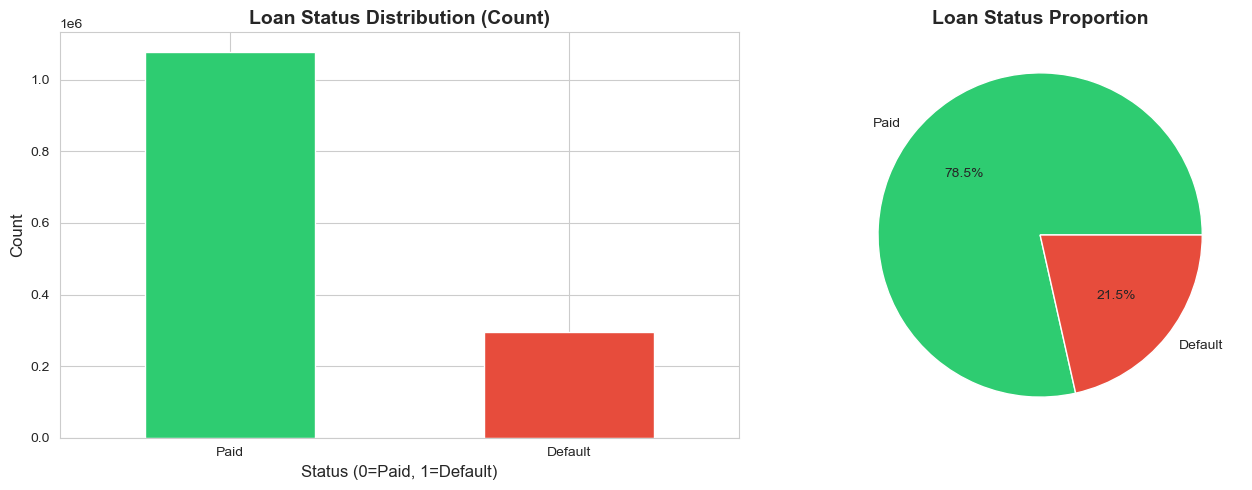

Plot saved to figures/target_distribution.png


In [380]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Loan Status Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status (0=Paid, 1=Default)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Paid', 'Default'], rotation=0)

# Pie chart
df['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=['#2ecc71', '#e74c3c'], labels=['Paid', 'Default'])
axes[1].set_title('Loan Status Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to figures/target_distribution.png")

## 3. Sampling



In [382]:
# Stratified sampling to maintain class distribution
# Using substantial portion of data as per project requirements
SAMPLE_SIZE = 700_000  # ~50% of 1.37M completed loans (substantial portion)

if len(df) > SAMPLE_SIZE:
    df_sampled = df.groupby('target', group_keys=False).apply(
        lambda x: x.sample(int(SAMPLE_SIZE * len(x) / len(df)), random_state=42)
    )
    print(f"Sampled {len(df_sampled):,} rows (stratified by target)")
else:
    df_sampled = df.copy()
    print(f"Using full dataset: {len(df_sampled):,} rows")

# Verify class distribution is maintained
print(f"\nClass distribution after sampling:")
print(f"0 (Paid): {(df_sampled['target'] == 0).sum():,} ({(df_sampled['target'] == 0).sum() / len(df_sampled) * 100:.1f}%)")
print(f"1 (Default): {(df_sampled['target'] == 1).sum():,} ({(df_sampled['target'] == 1).sum() / len(df_sampled) * 100:.1f}%)")

# Use sampled data from now on
df = df_sampled.copy()
del df_sampled  # Free memory

Sampled 699,999 rows (stratified by target)

Class distribution after sampling:
0 (Paid): 549,609 (78.5%)
1 (Default): 150,390 (21.5%)


## 4. Feature Selection

### Avoiding Data Leakage

**Data leakage** = Using information that wouldn't be available at prediction time

**Features to EXCLUDE** (post-loan information):
- `last_pymnt_*` - Payment history (known AFTER loan outcome)
- `total_pymnt_*` - Total payments made
- `total_rec_*` - Total recovered amounts
- `out_prncp*` - Outstanding principal
- `recoveries`, `collection_recovery_fee`
- Any feature with: `last_`, `total_`, `rec_`, `pymnt`, `out_`, `recovery`

**Features to INCLUDE** (available at application time):
- Borrower info: `annual_inc`, `emp_length`, `home_ownership`, `dti`
- Credit history: `fico_range_low`, `fico_range_high`, `delinq_2yrs`, etc.
- Loan details: `loan_amnt`, `term`, `int_rate`, `grade`, `purpose`

In [384]:
# Check missing values for all columns
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Top 20 columns with missing values:")
print(missing_pct[missing_pct > 0].head(20))

Top 20 columns with missing values:
member_id                                     100.000000
orig_projected_additional_accrued_interest     99.604428
hardship_loan_status                           99.451285
hardship_end_date                              99.451285
payment_plan_start_date                        99.451285
hardship_length                                99.451285
hardship_dpd                                   99.451285
hardship_payoff_balance_amount                 99.451285
hardship_last_payment_amount                   99.451285
hardship_type                                  99.451285
hardship_status                                99.451285
hardship_start_date                            99.451285
hardship_amount                                99.451285
deferral_term                                  99.451285
hardship_reason                                99.451285
sec_app_mths_since_last_major_derog            99.431142
sec_app_revol_util                             98.47

In [385]:
# need to make sure nothing leaks from after loan decision
# checked the data dictionary, these should all be available when applying

selected_features = [
    # Loan amount and terms
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    
    # Borrower information
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    
    # Loan purpose
    'purpose',
    
    # Debt metrics
    'dti',  # Debt-to-income ratio
    'delinq_2yrs',  # Delinquencies in last 2 years
    'inq_last_6mths',  # Credit inquiries
    
    # Credit history
    'fico_range_low',
    'fico_range_high',
    'open_acc',  # Number of open accounts
    'pub_rec',  # Public records
    'revol_bal',  # Revolving balance
    'revol_util',  # Revolving utilization
    'total_acc',  # Total accounts
    
    # Address (for geographic analysis - optional)
    'addr_state',
]

# Add target
selected_features.append('target')

print(f"Selected {len(selected_features) - 1} features (plus target)")
print(f"\nFeatures: {', '.join(selected_features[:-1])}")

Selected 22 features (plus target)

Features: loan_amnt, term, int_rate, installment, grade, sub_grade, emp_length, home_ownership, annual_inc, verification_status, purpose, dti, delinq_2yrs, inq_last_6mths, fico_range_low, fico_range_high, open_acc, pub_rec, revol_bal, revol_util, total_acc, addr_state


In [386]:
# Check if all selected features exist
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f" Features not found: {missing_features}")
else:
    print(" All selected features are present in the dataset")

# Create working dataframe with selected features only
df_clean = df[selected_features].copy()
print(f"\n Working dataframe created with shape: {df_clean.shape}")

 All selected features are present in the dataset

 Working dataframe created with shape: (699999, 23)


## 5. Data Cleaning

In [388]:
# Check data types
print("Data types:")
print(df_clean.dtypes)

print("\n" + "="*50)
print("Missing values:")
missing = (df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=False)
print(missing[missing > 0])

Data types:
loan_amnt              float64
term                    object
int_rate               float64
installment            float64
grade                   object
sub_grade               object
emp_length              object
home_ownership          object
annual_inc             float64
verification_status     object
purpose                 object
dti                    float64
delinq_2yrs            float64
inq_last_6mths         float64
fico_range_low         float64
fico_range_high        float64
open_acc               float64
pub_rec                float64
revol_bal              float64
revol_util             float64
total_acc              float64
addr_state              object
target                   int64
dtype: object

Missing values:
emp_length        5.883723
revol_util        0.064857
dti               0.029000
inq_last_6mths    0.002286
delinq_2yrs       0.002143
total_acc         0.002143
pub_rec           0.002143
open_acc          0.002143
dtype: float64


In [389]:
# Convert percentage strings to floats
if df_clean['int_rate'].dtype == 'object':
    df_clean['int_rate'] = df_clean['int_rate'].str.rstrip('%').astype('float')
    print(" Converted int_rate to float")

if df_clean['revol_util'].dtype == 'object':
    df_clean['revol_util'] = df_clean['revol_util'].str.rstrip('%').astype('float')
    print(" Converted revol_util to float")

In [390]:
# Convert term to numeric (36 months -> 36)
df_clean['term'] = df_clean['term'].str.extract(r'(\d+)').astype(int)
print(" Converted term to numeric")

# Create FICO score (average of low and high)
df_clean['fico_score'] = (df_clean['fico_range_low'] + df_clean['fico_range_high']) / 2
df_clean = df_clean.drop(['fico_range_low', 'fico_range_high'], axis=1)
print("Created fico_score feature")

 Converted term to numeric
Created fico_score feature


In [391]:
# Handle missing values
print("Handling missing values...")

# For numeric features: impute with median
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('target')  # Don't impute target

for col in numeric_features:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"  - Imputed {col} with median: {median_val:.2f}")

# For categorical features: impute with mode
categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()

for col in categorical_features:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"  - Imputed {col} with mode: {mode_val}")

print(f"\n Missing values handled")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

Handling missing values...
  - Imputed dti with median: 17.64
  - Imputed delinq_2yrs with median: 0.00
  - Imputed inq_last_6mths with median: 0.00
  - Imputed open_acc with median: 11.00
  - Imputed pub_rec with median: 0.00
  - Imputed revol_util with median: 52.10
  - Imputed total_acc with median: 23.00
  - Imputed emp_length with mode: 10+ years

 Missing values handled
Remaining missing values: 0


## 6. Exploratory Data Analysis

In [393]:
# Summary statistics
print("Summary Statistics for Numeric Features:")
df_clean.describe()

Summary Statistics for Numeric Features:


,loan_amnt,term,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,target,fico_score
count,699999.000000,699999.000000,699999.000000,699999.000000,6.999990e+05,699999.000000,699999.000000,699999.000000,699999.000000,699999.000000,6.999990e+05,699999.000000,699999.000000,699999.000000,699999.000000
mean,14458.623584,41.859266,13.286656,439.011268,7.620643e+04,18.308358,0.318565,0.661948,11.591234,0.214913,1.625994e+04,51.785551,24.935468,0.214843,698.086659
std,8744.689758,10.309778,4.790791,262.059292,6.854593e+04,11.324448,0.882098,0.960099,5.492411,0.603509,2.253778e+04,24.530651,12.024548,0.410714,31.813761
min,500.000000,36.000000,5.310000,7.610000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000,617.000000
25%,8000.000000,36.000000,9.750000,249.010000,4.576750e+04,11.810000,0.000000,0.000000,8.000000,0.000000,5.923000e+03,33.400000,16.000000,0.000000,672.000000
50%,12000.000000,36.000000,12.790000,375.430000,6.500000e+04,17.640000,0.000000,0.000000,11.000000,0.000000,1.111600e+04,52.100000,23.000000,0.000000,692.000000
75%,20000.000000,36.000000,16.020000,581.690000,9.000000e+04,24.080000,0.000000,1.000000,14.000000,0.000000,1.974900e+04,70.700000,32.000000,0.000000,712.000000
max,40000.000000,60.000000,30.990000,1719.830000,9.550000e+06,999.000000,36.000000,32.000000,88.000000,63.000000,2.904836e+06,892.300000,173.000000,1.000000,847.500000


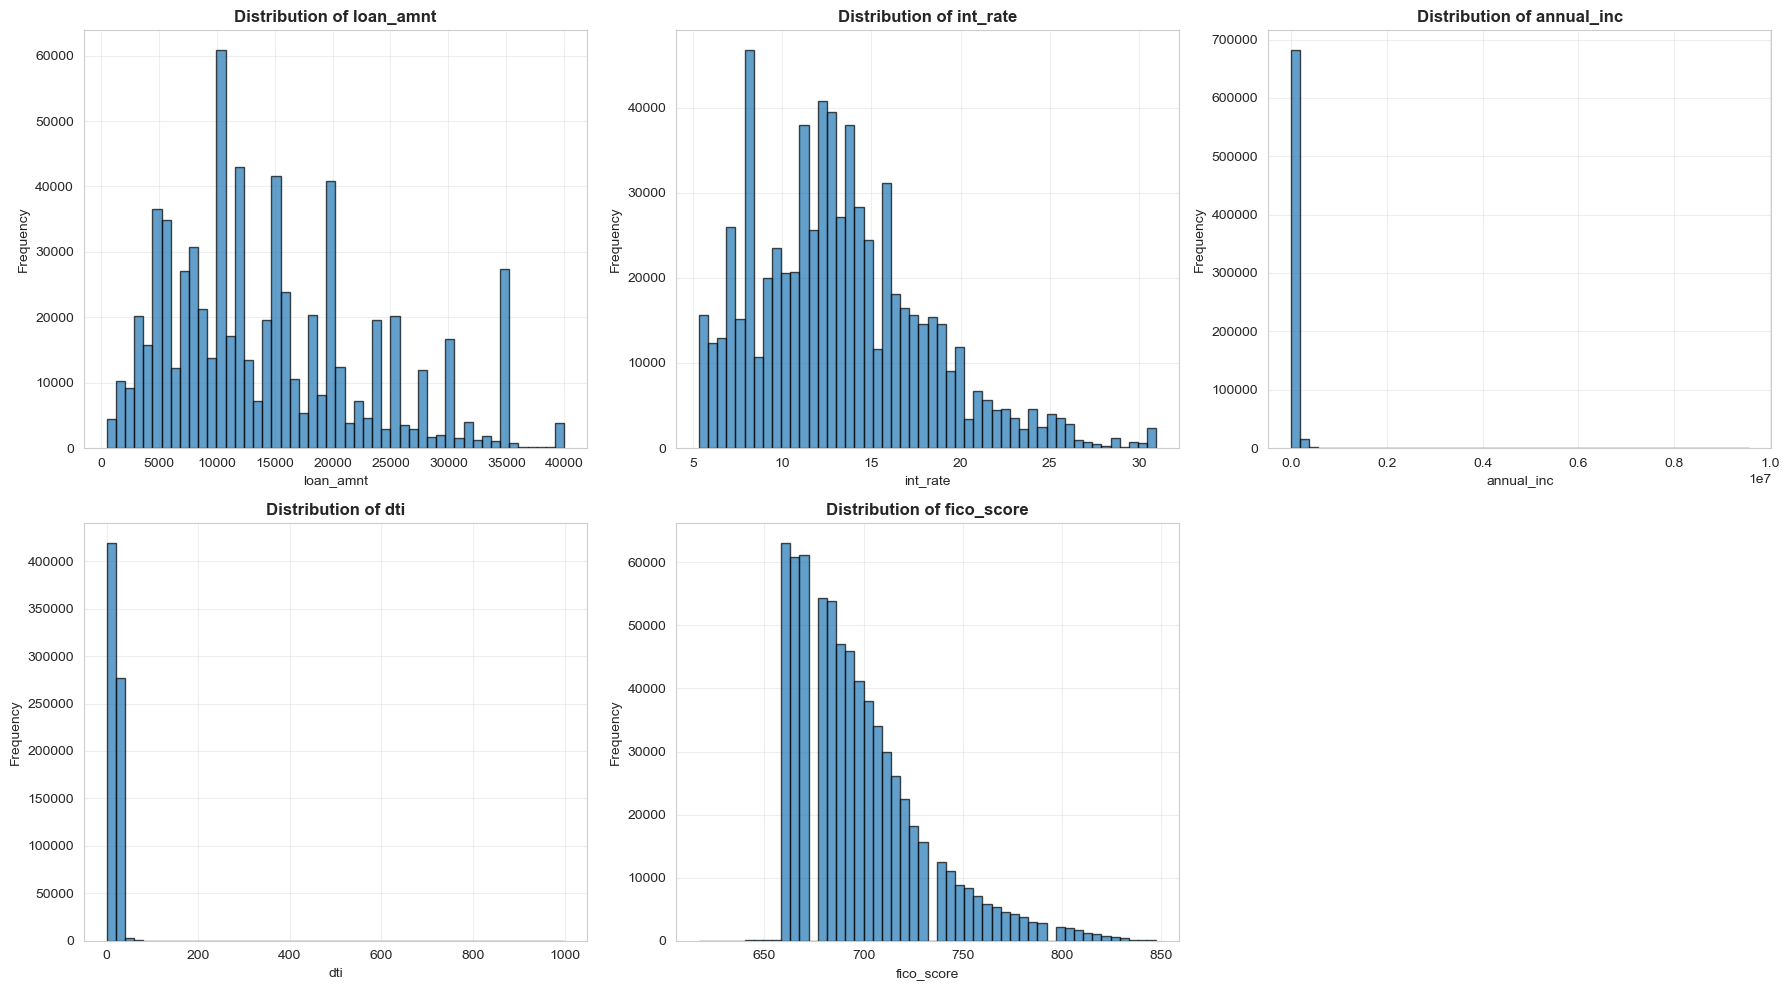

 Plot saved to figures/numeric_distributions.png


In [394]:
# Distribution of key numeric features
key_numeric = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_score']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(key_numeric):
    axes[idx].hist(df_clean[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'numeric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Plot saved to figures/numeric_distributions.png")

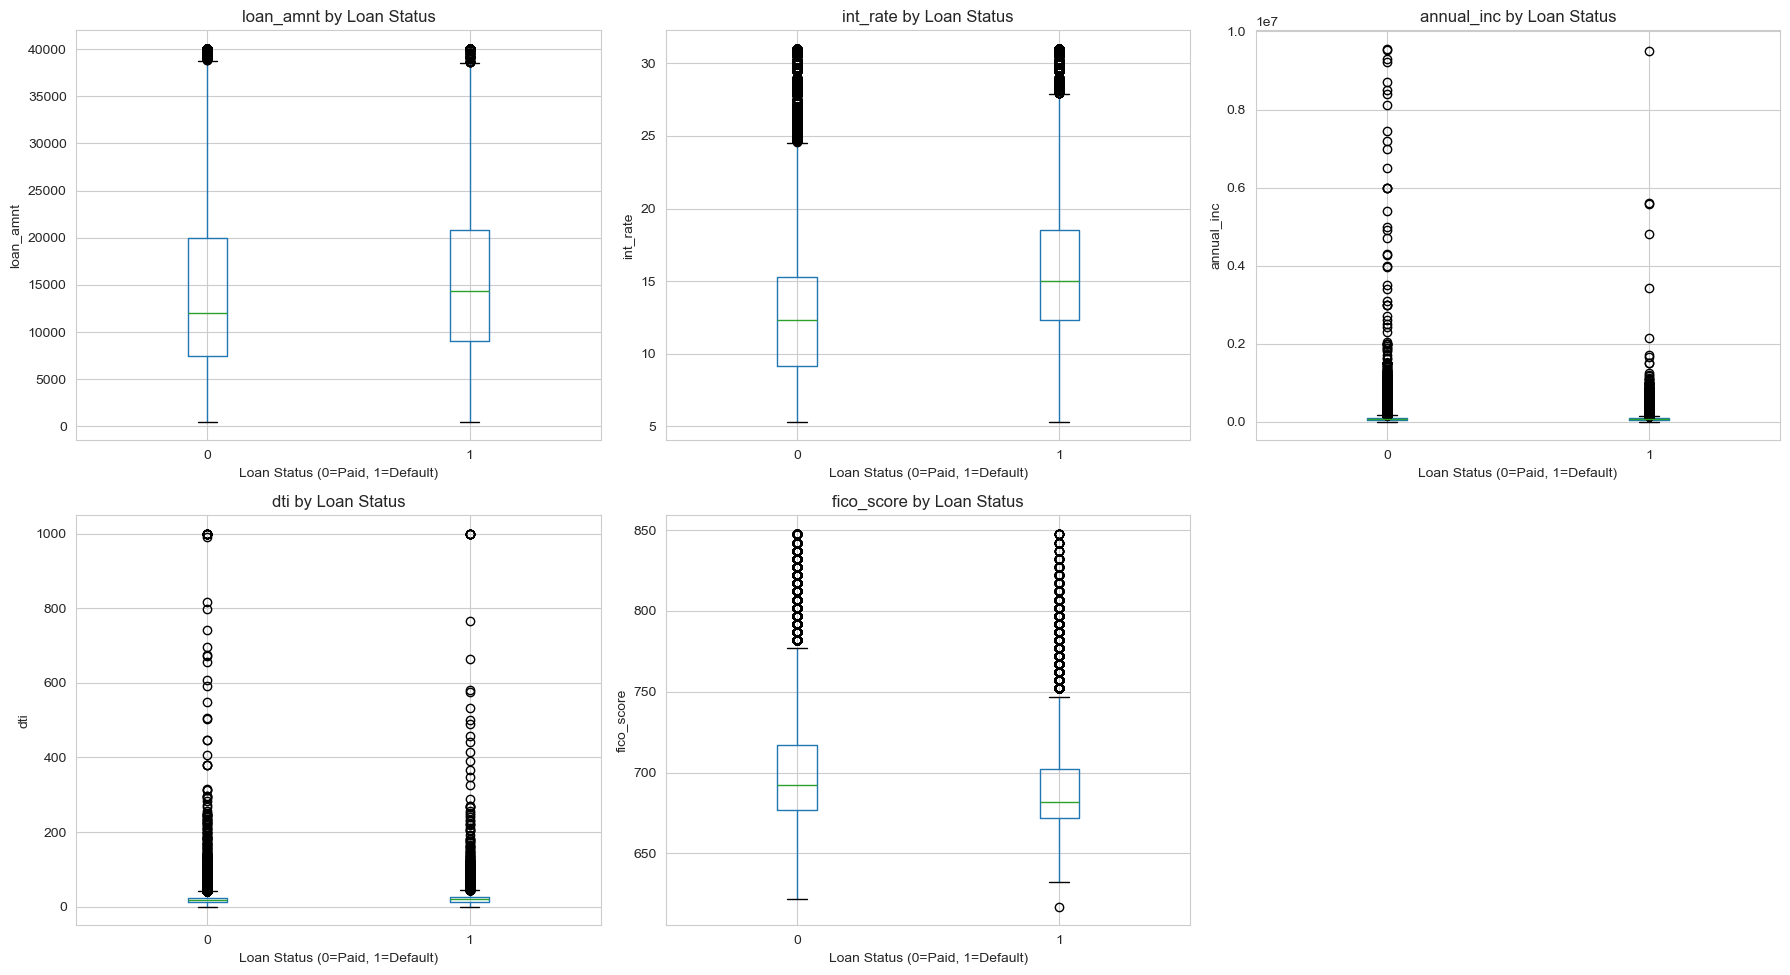

 Plot saved to figures/features_by_target.png


In [395]:
# Boxplots: Compare features by target
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(key_numeric):
    df_clean.boxplot(column=col, by='target', ax=axes[idx])
    axes[idx].set_title(f'{col} by Loan Status')
    axes[idx].set_xlabel('Loan Status (0=Paid, 1=Default)')
    axes[idx].set_ylabel(col)

fig.delaxes(axes[5])
plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'features_by_target.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Plot saved to figures/features_by_target.png")

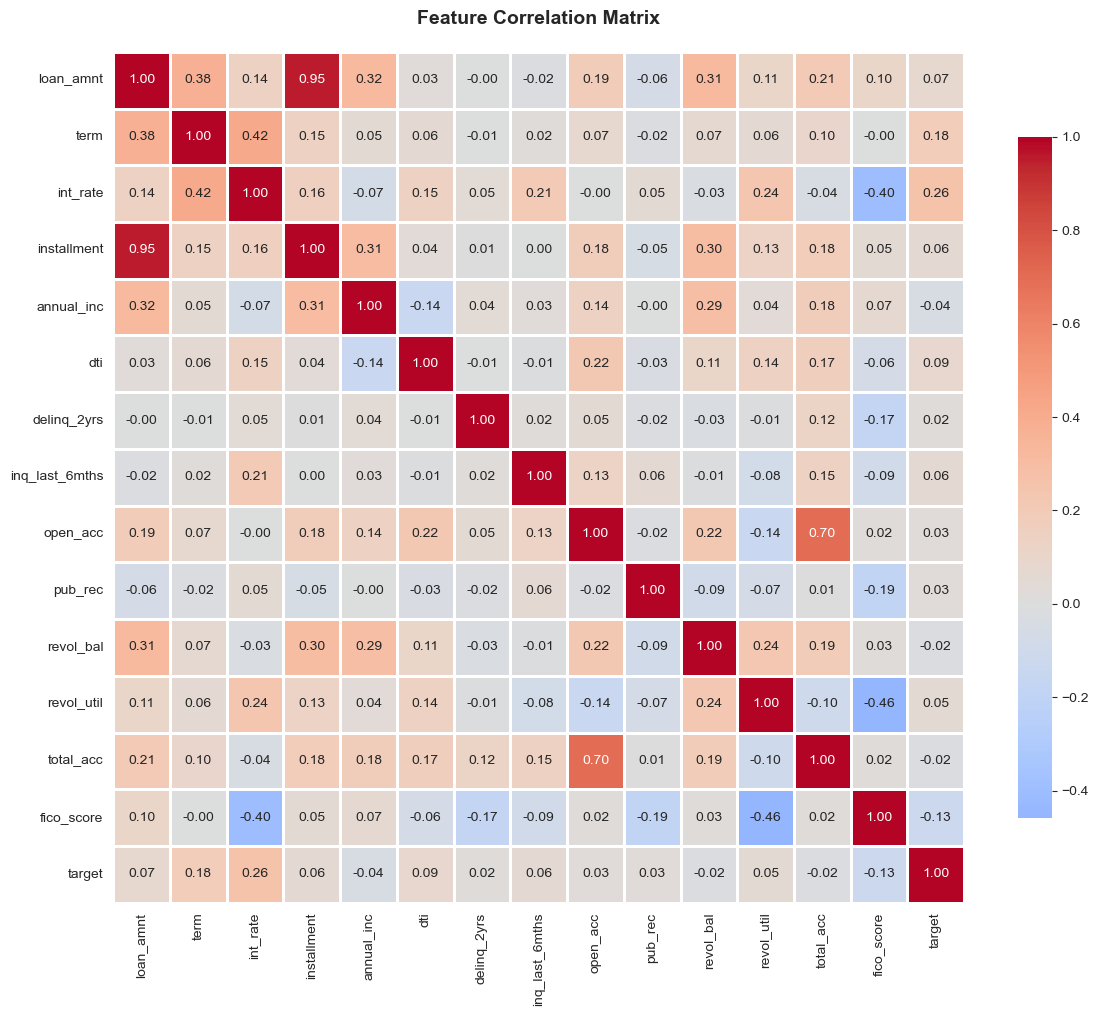

 Plot saved to figures/correlation_matrix.png


In [396]:
# Correlation matrix
plt.figure(figsize=(12, 10))
correlation = df_clean[numeric_features + ['target']].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Plot saved to figures/correlation_matrix.png")

In [397]:
# Categorical features analysis
categorical_cols = ['grade', 'purpose', 'home_ownership']

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"{col.upper()} Distribution:")
    print(df_clean[col].value_counts())
    
    # Default rate by category
    default_rate = df_clean.groupby(col)['target'].mean().sort_values(ascending=False)
    print(f"\nDefault Rate by {col}:")
    print(default_rate)


GRADE Distribution:
grade
B    203023
C    199160
A    120927
D    105711
E     49419
F     16828
G      4931
Name: count, dtype: int64

Default Rate by grade:
grade
G    0.510850
F    0.463632
E    0.400534
D    0.322511
C    0.242684
B    0.145959
A    0.067942
Name: target, dtype: float64

PURPOSE Distribution:
purpose
debt_consolidation    406011
credit_card           152829
home_improvement       45922
other                  40768
major_purchase         15254
medical                 8200
small_business          8126
car                     7510
moving                  4897
vacation                4744
house                   3801
wedding                 1225
renewable_energy         486
educational              226
Name: count, dtype: int64

Default Rate by purpose:
purpose
small_business        0.322545
renewable_energy      0.246914
house                 0.245988
moving                0.245456
medical               0.234268
other                 0.231652
debt_consolidation    0

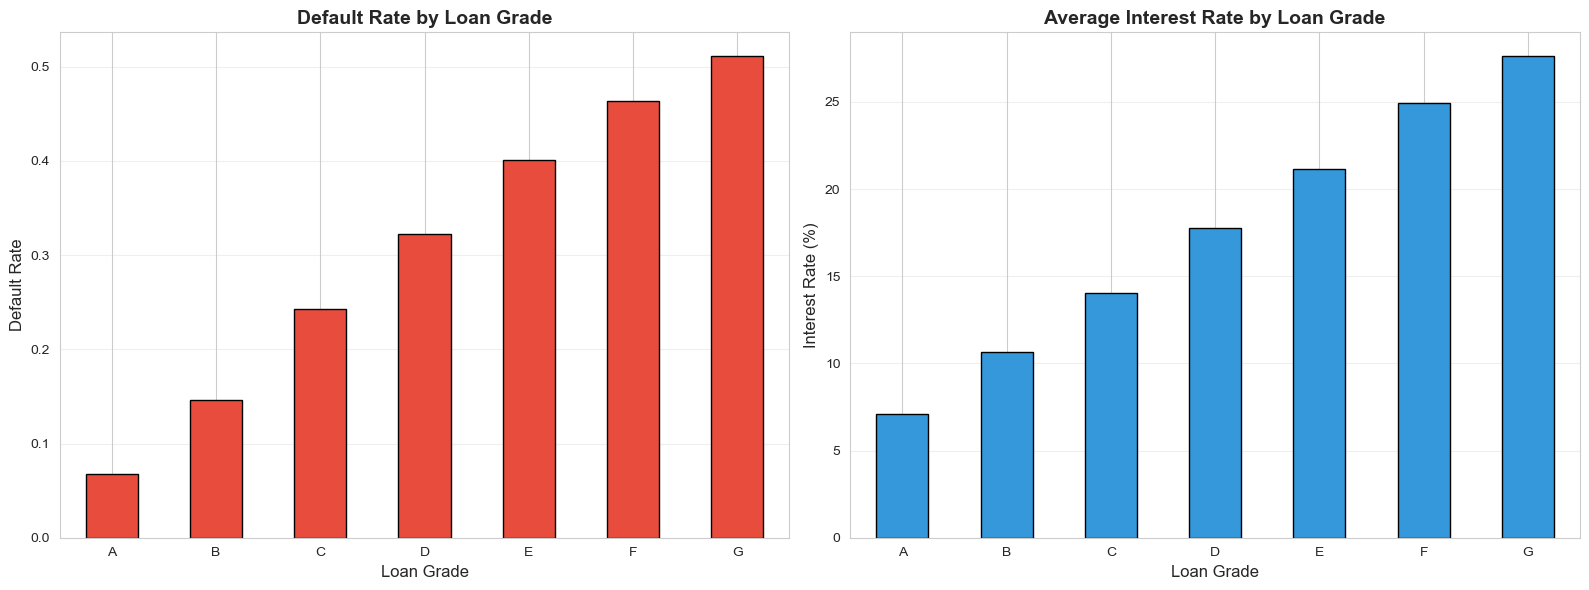

 Plot saved to figures/grade_analysis.png


In [398]:
# Visualize default rates by grade
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Default rate by grade
default_by_grade = df_clean.groupby('grade')['target'].mean().sort_index()
default_by_grade.plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Default Rate by Loan Grade', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Grade', fontsize=12)
axes[0].set_ylabel('Default Rate', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(alpha=0.3, axis='y')

# Interest rate by grade
df_clean.groupby('grade')['int_rate'].mean().plot(kind='bar', ax=axes[1], 
                                                     color='#3498db', edgecolor='black')
axes[1].set_title('Average Interest Rate by Loan Grade', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Loan Grade', fontsize=12)
axes[1].set_ylabel('Interest Rate (%)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'grade_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Plot saved to figures/grade_analysis.png")

## 7. Feature Engineering

In [400]:
# Encode categorical variables
print("Encoding categorical variables...")

# Label encoding for ordinal features (grade has natural order A < B < C...)
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_clean['grade_encoded'] = df_clean['grade'].map(grade_mapping)
print(" Encoded grade (ordinal)")

# For sub_grade, create numeric encoding
subgrade_order = sorted(df_clean['sub_grade'].unique())
subgrade_mapping = {grade: idx for idx, grade in enumerate(subgrade_order, 1)}
df_clean['sub_grade_encoded'] = df_clean['sub_grade'].map(subgrade_mapping)
print(" Encoded sub_grade (ordinal)")

# Label encoding for other categorical features
le_columns = ['home_ownership', 'verification_status', 'purpose', 'addr_state', 'emp_length']

label_encoders = {}
for col in le_columns:
    le = LabelEncoder()
    df_clean[f'{col}_encoded'] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f" Encoded {col}")

print(f"\n All categorical variables encoded")

Encoding categorical variables...
 Encoded grade (ordinal)
 Encoded sub_grade (ordinal)
 Encoded home_ownership
 Encoded verification_status
 Encoded purpose
 Encoded addr_state
 Encoded emp_length

 All categorical variables encoded


In [401]:
# Create final feature set
# Drop original categorical columns, keep encoded versions
columns_to_drop = ['grade', 'sub_grade'] + le_columns + ['loan_status'] if 'loan_status' in df_clean.columns else ['grade', 'sub_grade'] + le_columns

# Create feature matrix X and target y
feature_columns = [col for col in df_clean.columns if col not in columns_to_drop and col != 'target']

X = df_clean[feature_columns].copy()
y = df_clean['target'].copy()

print(f"Final feature set created")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {list(X.columns)}")
print(f"\nTarget distribution:")
print(f"Class 0 (Paid): {(y == 0).sum():,} ({(y == 0).sum() / len(y) * 100:.1f}%)")
print(f"Class 1 (Default): {(y == 1).sum():,} ({(y == 1).sum() / len(y) * 100:.1f}%)")

Final feature set created
Number of features: 21
Feature names: ['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'fico_score', 'grade_encoded', 'sub_grade_encoded', 'home_ownership_encoded', 'verification_status_encoded', 'purpose_encoded', 'addr_state_encoded', 'emp_length_encoded']

Target distribution:
Class 0 (Paid): 549,609 (78.5%)
Class 1 (Default): 150,390 (21.5%)


## 8. Train-Validation-Test Split

In [403]:
# Split: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp  # 0.1765 * 0.85 ≈ 0.15
)

print(" Data split completed")
print(f"\nTrain set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification
print(f"\nClass distribution:")
print(f"Train - Class 1: {(y_train == 1).sum() / len(y_train) * 100:.1f}%")
print(f"Val   - Class 1: {(y_val == 1).sum() / len(y_val) * 100:.1f}%")
print(f"Test  - Class 1: {(y_test == 1).sum() / len(y_test) * 100:.1f}%")

 Data split completed

Train set: 489,981 samples (70.0%)
Validation set: 105,018 samples (15.0%)
Test set: 105,000 samples (15.0%)

Class distribution:
Train - Class 1: 21.5%
Val   - Class 1: 21.5%
Test  - Class 1: 21.5%


## 9. Feature Scaling

In [405]:
# Standardize features (important for neural networks)
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled using StandardScaler")
print(f"\nScaled feature statistics (train set):")
print(f"Mean: {X_train_scaled.mean().mean():.4f} (should be ~0)")
print(f"Std: {X_train_scaled.std().mean():.4f} (should be ~1)")

Features scaled using StandardScaler

Scaled feature statistics (train set):
Mean: -0.0000 (should be ~0)
Std: 1.0000 (should be ~1)


## 10. Save Processed Data

In [407]:
# Save processed datasets
print("Saving processed data...")

# Save unscaled data (for RL agent which might need original distributions)
X_train.to_csv(PROCESSED_DATA_DIR / 'X_train.csv', index=False)
X_val.to_csv(PROCESSED_DATA_DIR / 'X_val.csv', index=False)
X_test.to_csv(PROCESSED_DATA_DIR / 'X_test.csv', index=False)
y_train.to_csv(PROCESSED_DATA_DIR / 'y_train.csv', index=False, header=True)
y_val.to_csv(PROCESSED_DATA_DIR / 'y_val.csv', index=False, header=True)
y_test.to_csv(PROCESSED_DATA_DIR / 'y_test.csv', index=False, header=True)

# Save scaled data (for deep learning)
X_train_scaled.to_csv(PROCESSED_DATA_DIR / 'X_train_scaled.csv', index=False)
X_val_scaled.to_csv(PROCESSED_DATA_DIR / 'X_val_scaled.csv', index=False)
X_test_scaled.to_csv(PROCESSED_DATA_DIR / 'X_test_scaled.csv', index=False)

# Save scaler for later use
joblib.dump(scaler, PROCESSED_DATA_DIR / 'scaler.pkl')

# Save label encoders
joblib.dump(label_encoders, PROCESSED_DATA_DIR / 'label_encoders.pkl')

# Save feature names
with open(PROCESSED_DATA_DIR / 'feature_names.txt', 'w') as f:
    f.write('\n'.join(X_train.columns))

# Also save the full cleaned dataframe for reference
df_clean.to_csv(PROCESSED_DATA_DIR / 'df_cleaned.csv', index=False)

print("\n All processed data saved!")
print(f"Location: {PROCESSED_DATA_DIR}")
print(f"\nFiles saved:")
for file in PROCESSED_DATA_DIR.glob('*'):
    print(f"  - {file.name}")

Saving processed data...

 All processed data saved!
Location: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/data/processed

Files saved:
  - scaler.pkl
  - preprocessing_summary.json
  - X_train_scaled.csv
  - X_val_scaled.csv
  - y_val.csv
  - X_train.csv
  - X_val.csv
  - feature_names.txt
  - label_encoders.pkl
  - df_cleaned.csv
  - y_train.csv
  - y_test.csv
  - X_test.csv
  - X_test_scaled.csv


## 11. Summary Statistics for Report

In [409]:
# Create summary for report
summary = {
    'Original Dataset Size': f"{len(df_raw):,} rows",
    'Filtered Dataset Size': f"{len(df):,} rows",
    'Number of Features': len(X.columns),
    'Train Set Size': f"{len(X_train):,} rows",
    'Validation Set Size': f"{len(X_val):,} rows",
    'Test Set Size': f"{len(X_test):,} rows",
    'Class Balance (Default Rate)': f"{(y == 1).sum() / len(y) * 100:.1f}%",
    'Feature Engineering Steps': [
        'Removed data leakage features',
        'Created FICO score from range',
        'Encoded categorical variables',
        'Standardized numeric features'
    ]
}

print("="*60)
print("TASK 1 SUMMARY: DATA PREPROCESSING")
print("="*60)
for key, value in summary.items():
    if isinstance(value, list):
        print(f"\n{key}:")
        for item in value:
            print(f"  - {item}")
    else:
        print(f"{key}: {value}")
print("="*60)

# Save summary
import json
with open(PROCESSED_DATA_DIR / 'preprocessing_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\nSummary saved to preprocessing_summary.json")

TASK 1 SUMMARY: DATA PREPROCESSING
Original Dataset Size: 2,260,701 rows
Filtered Dataset Size: 699,999 rows
Number of Features: 21
Train Set Size: 489,981 rows
Validation Set Size: 105,018 rows
Test Set Size: 105,000 rows
Class Balance (Default Rate): 21.5%

Feature Engineering Steps:
  - Removed data leakage features
  - Created FICO score from range
  - Encoded categorical variables
  - Standardized numeric features

Summary saved to preprocessing_summary.json
